In [1]:
# ============================================
# ASSIGNMENT 05 - ARTIFICIAL NEURAL NETWORKS
# MOBILE PRICE CLASSIFICATION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
!pip install -q gdown
import gdown

file_id = "1YNuSslEtvOXx3_whqdY54ZqIuBGvRUvd"

download_url = f"https://drive.google.com/uc?id={file_id}"

output_file = "mobile_price_classification.csv"

gdown.download(
    download_url,
    output_file,
    quiet=False
)

print("Dataset downloaded successfully.")

Downloading...
From: https://drive.google.com/uc?id=1YNuSslEtvOXx3_whqdY54ZqIuBGvRUvd
To: /content/mobile_price_classification.csv
100%|██████████| 124k/124k [00:00<00:00, 31.5MB/s]

Dataset downloaded successfully.


In [3]:
df = pd.read_csv("mobile_price_classification.csv")

print("Dataset loaded successfully.")

display(df.head())

Dataset loaded successfully.


,battery_power,bluetooth,clock_speed,dual_sim,front_cam,4G,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (2000, 21)


In [5]:
print("Column Names:")

print(df.columns.tolist())

Column Names:
['battery_power', 'bluetooth', 'clock_speed', 'dual_sim', 'front_cam', '4G', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'primary_camera', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi', 'price_range']


In [6]:
display(df.head(10))

,battery_power,bluetooth,clock_speed,dual_sim,front_cam,4G,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
5,1859,0,0.5,1,3,0,22,0.7,164,1,...,1004,1654,1067,17,1,10,1,0,0,1
6,1821,0,1.7,0,4,1,10,0.8,139,8,...,381,1018,3220,13,8,18,1,0,1,3
7,1954,0,0.5,1,0,0,24,0.8,187,4,...,512,1149,700,16,3,5,1,1,1,0
8,1445,1,0.5,0,0,0,53,0.7,174,7,...,386,836,1099,17,1,20,1,0,0,0
9,509,1,0.6,1,2,1,9,0.1,93,5,...,1137,1224,513,19,10,12,1,0,0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   battery_power   2000 non-null   int64  
 1   bluetooth       2000 non-null   int64  
 2   clock_speed     2000 non-null   float64
 3   dual_sim        2000 non-null   int64  
 4   front_cam       2000 non-null   int64  
 5   4G              2000 non-null   int64  
 6   int_memory      2000 non-null   int64  
 7   m_dep           2000 non-null   float64
 8   mobile_wt       2000 non-null   int64  
 9   n_cores         2000 non-null   int64  
 10  primary_camera  2000 non-null   int64  
 11  px_height       2000 non-null   int64  
 12  px_width        2000 non-null   int64  
 13  ram             2000 non-null   int64  
 14  sc_h            2000 non-null   int64  
 15  sc_w            2000 non-null   int64  
 16  talk_time       2000 non-null   int64  
 17  three_g         2000 non-null   i

In [8]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
bluetooth,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
front_cam,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
4G,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


In [10]:
print("Unique Price Classes:")

print(df["price_range"].unique())

Unique Price Classes:
[1 2 3 0]


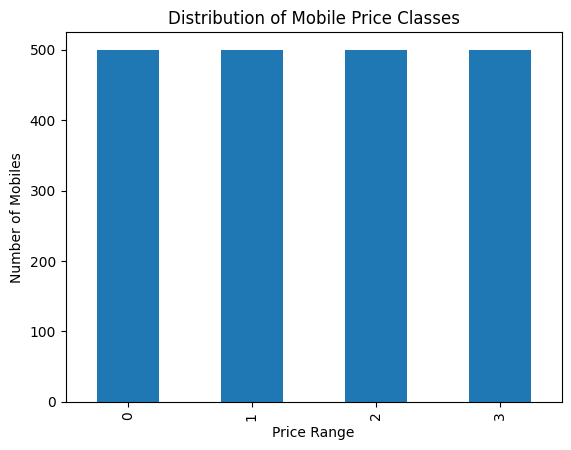

In [11]:
df["price_range"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribution of Mobile Price Classes")
plt.xlabel("Price Range")
plt.ylabel("Number of Mobiles")
plt.show()

In [12]:
missing_values = df.isnull().sum()

print("Missing Values:")

print(missing_values)

Missing Values:
battery_power     0
bluetooth         0
clock_speed       0
dual_sim          0
front_cam         0
4G                0
int_memory        0
m_dep             0
mobile_wt         0
n_cores           0
primary_camera    0
px_height         0
px_width          0
ram               0
sc_h              0
sc_w              0
talk_time         0
three_g           0
touch_screen      0
wifi              0
price_range       0
dtype: int64


In [13]:
print(
    "Total Missing Values:",
    df.isnull().sum().sum()
)

Total Missing Values: 0


In [14]:
# Numerical columns
numerical_columns = df.select_dtypes(
    include=np.number
).columns

for column in numerical_columns:
    if column != "price_range":
        df[column] = df[column].fillna(
            df[column].median()
        )

In [15]:
print(
    "Missing values after treatment:",
    df.isnull().sum().sum()
)

Missing values after treatment: 0


In [16]:
print(
    "Number of duplicate rows:",
    df.duplicated().sum()
)

Number of duplicate rows: 0


In [17]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (2000, 21)


In [18]:
X = df.drop(
    columns=["price_range"]
)

y = df["price_range"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (2000, 20)
Target Shape: (2000,)


In [19]:
display(X.head())

,battery_power,bluetooth,clock_speed,dual_sim,front_cam,4G,int_memory,m_dep,mobile_wt,n_cores,primary_camera,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0


In [20]:
display(y.head())

,price_range
0,1
1,2
2,2
3,2
4,1


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (1600, 20)
Testing Features : (400, 20)
Training Labels  : (1600,)
Testing Labels   : (400,)


In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Feature scaling completed.")

Feature scaling completed.


In [23]:
print(X_train_scaled[:5])

[[ 1.38919326  1.011314   -1.25918898  0.98634324  1.30925256 -1.03693152
   1.58482903 -0.70458975 -1.25033529 -1.5516371   0.35023908 -0.79884868
  -1.28564151 -0.36302366 -0.78128983 -0.17762722 -0.89664506 -1.78870765
  -1.00878862 -1.02532046]
 [ 0.07840603  1.011314   -1.25918898 -1.01384584  1.77045998 -1.03693152
  -0.00345726 -1.39684863 -0.76837395  1.0731587   0.84454887  1.58230174
   1.63767503 -1.54789561  0.64708236  1.87520744  0.56094407 -1.78870765
  -1.00878862  0.97530483]
 [-1.02457347 -0.98881258  1.18747125  0.98634324 -0.0743697   0.96438384
   1.36575506  1.37218691 -1.39208862  1.51062466  0.35023908 -1.36150237
  -0.19930538  1.69898521 -0.06710374  0.506651   -0.89664506  0.55906285
   0.99128795  0.97530483]
 [ 0.38669222 -0.98881258 -1.25918898  0.98634324 -0.53557712  0.96438384
   0.10607972  1.02605747 -1.19363396 -0.67670517 -0.80315042  0.83284703
   0.27858927  1.64923164 -0.78128983  0.506651   -1.62543963  0.55906285
  -1.00878862  0.97530483]
 [-0

In [24]:
model = Sequential()

# First hidden layer
model.add(
    Dense(
        64,
        activation="relu",
        input_shape=(X_train_scaled.shape[1],)
    )
)

# Prevent overfitting
model.add(
    Dropout(0.2)
)

# Second hidden layer
model.add(
    Dense(
        32,
        activation="relu"
    )
)

model.add(
    Dropout(0.2)
)

# Output layer
model.add(
    Dense(
        4,
        activation="softmax"
    )
)

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,556 (13.89 KB)

 Trainable params: 3,556 (13.89 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [28]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [29]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.2703 - loss: 1.4433 - val_accuracy: 0.3063 - val_loss: 1.3615
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3969 - loss: 1.3032 - val_accuracy: 0.4500 - val_loss: 1.2494
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4852 - loss: 1.1519 - val_accuracy: 0.5312 - val_loss: 1.0708
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5648 - loss: 0.9862 - val_accuracy: 0.6094 - val_loss: 0.8744
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6414 - loss: 0.8247 - val_accuracy: 0.7188 - val_loss: 0.7126
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7000 - loss: 0.7188 - val_accuracy: 0.7969 - val_loss: 0.6086
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7398 - loss: 0.6141 - val_accuracy: 0.8188 - val_loss: 0.5296
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7812 - loss: 0.5602 - val_accuracy: 0.8562 - 

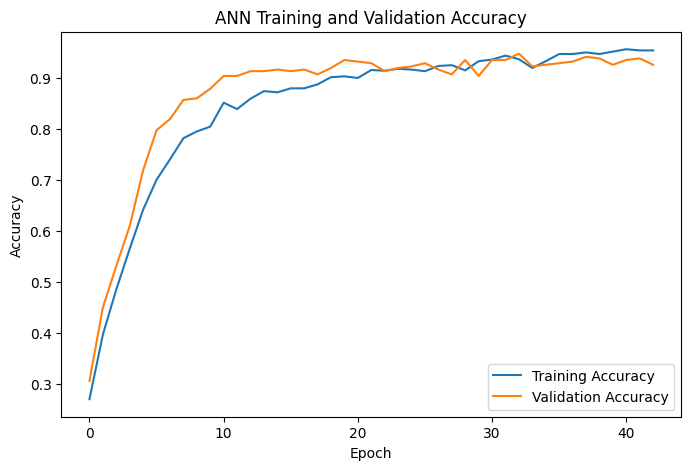

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN Training and Validation Accuracy")
plt.legend()
plt.show()

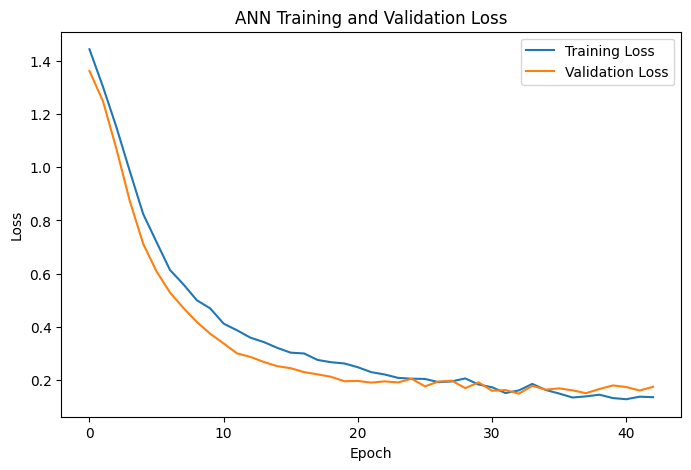

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training and Validation Loss")
plt.legend()
plt.show()

In [32]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.15657129883766174
Test Accuracy: 0.9300000071525574


In [33]:
print(
    f"ANN Test Accuracy: {test_accuracy * 100:.2f}%"
)

ANN Test Accuracy: 93.00%


In [34]:
y_pred_prob = model.predict(
    X_test_scaled
)

print(y_pred_prob[:5])

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
[[4.1102249e-25 1.8196011e-12 5.3362263e-04 9.9946630e-01]
 [9.0148191e-05 9.0337878e-01 9.6530207e-02 7.5343610e-07]
 [9.9924743e-01 7.5262348e-04 1.8180753e-12 8.6256721e-28]
 [1.9811109e-06 5.4844771e-02 9.4497806e-01 1.7508790e-04]
 [6.9349058e-20 2.3996354e-09 1.1023469e-02 9.8897654e-01]]


In [35]:
y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

print("Predicted Classes:")

print(y_pred[:20])

Predicted Classes:
[3 1 0 2 3 2 0 0 1 0 3 0 0 1 3 3 2 0 1 3]


In [36]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy Score: {accuracy * 100:.2f}%"
)

Accuracy Score: 93.00%


In [37]:
print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       100
           1       0.91      0.92      0.92       100
           2       0.90      0.91      0.91       100
           3       0.95      0.94      0.94       100

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400



In [38]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")

print(cm)

Confusion Matrix:
[[95  5  0  0]
 [ 4 92  4  0]
 [ 0  4 91  5]
 [ 0  0  6 94]]


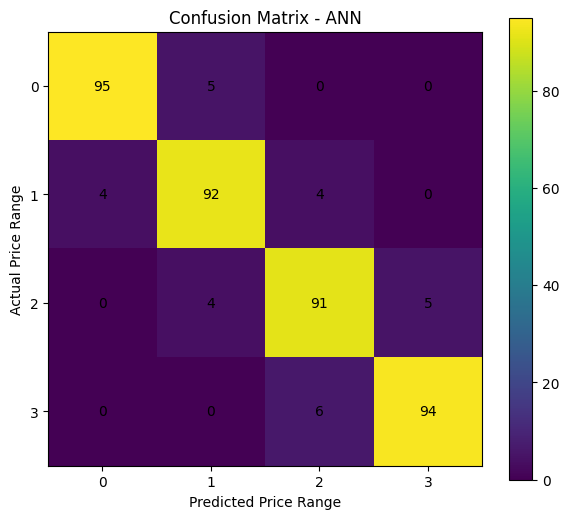

In [39]:
plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("Confusion Matrix - ANN")
plt.xlabel("Predicted Price Range")
plt.ylabel("Actual Price Range")

plt.xticks(
    range(4),
    ["0", "1", "2", "3"]
)

plt.yticks(
    range(4),
    ["0", "1", "2", "3"]
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [40]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.8 MB/s eta 0:00:00


In [41]:
import keras_tuner as kt

In [42]:
def build_model(hp):

    model = Sequential()

    # First hidden layer
    model.add(
        Dense(
            units=hp.Int(
                "units_1",
                min_value=32,
                max_value=128,
                step=32
            ),
            activation=hp.Choice(
                "activation",
                values=["relu", "tanh"]
            ),
            input_shape=(X_train_scaled.shape[1],)
        )
    )

    # Dropout
    model.add(
        Dropout(
            hp.Float(
                "dropout_1",
                min_value=0.0,
                max_value=0.5,
                step=0.1
            )
        )
    )

    # Second hidden layer
    model.add(
        Dense(
            units=hp.Int(
                "units_2",
                min_value=16,
                max_value=64,
                step=16
            ),
            activation=hp.Choice(
                "activation_2",
                values=["relu", "tanh"]
            )
        )
    )

    # Second dropout
    model.add(
        Dropout(
            hp.Float(
                "dropout_2",
                min_value=0.0,
                max_value=0.5,
                step=0.1
            )
        )
    )

    # Output layer
    model.add(
        Dense(
            4,
            activation="softmax"
        )
    )

    # Learning rate
    learning_rate = hp.Choice(
        "learning_rate",
        values=[
            0.01,
            0.001,
            0.0001
        ]
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [43]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=15,
    executions_per_trial=1,
    directory="mobile_ann_tuning",
    project_name="mobile_price_classification",
    overwrite=True
)

In [44]:
tuner.search_space_summary()

Search space summary
Default search space size: 7
units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh'], 'ordered': False}
dropout_1 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
units_2 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 64, 'step': 16, 'sampling': 'linear'}
activation_2 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh'], 'ordered': False}
dropout_2 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


In [45]:
tuner.search(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Trial 15 Complete [00h 00m 05s]
val_accuracy: 0.8218749761581421

Best val_accuracy So Far: 0.940625011920929
Total elapsed time: 00h 01m 25s


In [47]:
best_hps = tuner.get_best_hyperparameters(
    num_trials=1
)[0]

In [48]:
print("Best Hyperparameters")

print(
    "First Layer Neurons:",
    best_hps.get("units_1")
)

print(
    "First Layer Activation:",
    best_hps.get("activation")
)

print(
    "Dropout 1:",
    best_hps.get("dropout_1")
)

print(
    "Second Layer Neurons:",
    best_hps.get("units_2")
)

print(
    "Second Layer Activation:",
    best_hps.get("activation_2")
)

print(
    "Dropout 2:",
    best_hps.get("dropout_2")
)

print(
    "Learning Rate:",
    best_hps.get("learning_rate")
)

Best Hyperparameters
First Layer Neurons: 64
First Layer Activation: tanh
Dropout 1: 0.0
Second Layer Neurons: 64
Second Layer Activation: tanh
Dropout 2: 0.2
Learning Rate: 0.001


In [49]:
best_model = tuner.get_best_models(
    num_models=1
)[0]

best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,764 (22.52 KB)

 Trainable params: 5,764 (22.52 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
tuned_model = tuner.hypermodel.build(
    best_hps
)

In [51]:
tuned_history = tuned_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4031 - loss: 1.2585 - val_accuracy: 0.5625 - val_loss: 1.0299
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6055 - loss: 0.9090 - val_accuracy: 0.6406 - val_loss: 0.8098
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6953 - loss: 0.7339 - val_accuracy: 0.6875 - val_loss: 0.6837
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7484 - loss: 0.6212 - val_accuracy: 0.7750 - val_loss: 0.5784
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8086 - loss: 0.5338 - val_accuracy: 0.8406 - val_loss: 0.4934
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8453 - loss: 0.4564 - val_accuracy: 0.8719 - val_loss: 0.4287
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8930 - loss: 0.3859 - val_accuracy: 0.9000 - val_loss: 0.3630
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9078 - loss: 0.3402 - val_accuracy: 0.90

In [52]:
tuned_loss, tuned_accuracy = tuned_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(
    f"Tuned ANN Accuracy: {tuned_accuracy * 100:.2f}%"
)

print(
    f"Tuned ANN Loss: {tuned_loss:.4f}"
)

Tuned ANN Accuracy: 60.50%
Tuned ANN Loss: 1.0082


In [53]:
tuned_loss, tuned_accuracy = tuned_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(
    f"Tuned ANN Accuracy: {tuned_accuracy * 100:.2f}%"
)

print(
    f"Tuned ANN Loss: {tuned_loss:.4f}"
)

Tuned ANN Accuracy: 60.50%
Tuned ANN Loss: 1.0082


In [54]:
tuned_probabilities = tuned_model.predict(
    X_test_scaled
)

tuned_predictions = np.argmax(
    tuned_probabilities,
    axis=1
)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [55]:
print(
    classification_report(
        y_test,
        tuned_predictions
    )
)

              precision    recall  f1-score   support

           0       0.63      0.96      0.76       100
           1       0.62      0.28      0.39       100
           2       0.52      0.43      0.47       100
           3       0.62      0.75      0.68       100

    accuracy                           0.60       400
   macro avg       0.60      0.60      0.57       400
weighted avg       0.60      0.60      0.57       400



In [56]:
tuned_cm = confusion_matrix(
    y_test,
    tuned_predictions
)

print(tuned_cm)

[[96  4  0  0]
 [47 28 15 10]
 [ 9 13 43 35]
 [ 0  0 25 75]]


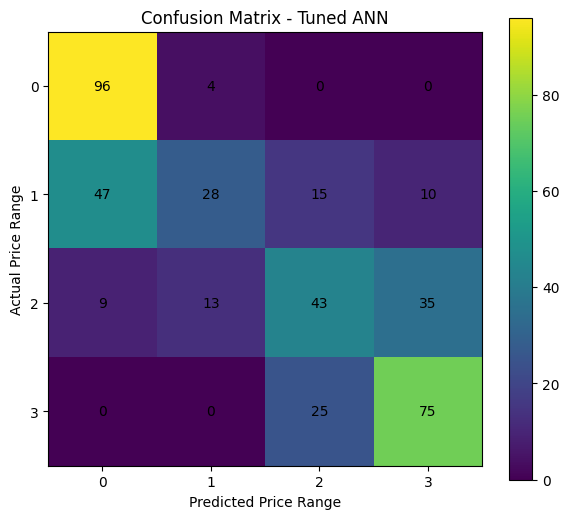

In [57]:
plt.figure(figsize=(7, 6))

plt.imshow(tuned_cm)

plt.title(
    "Confusion Matrix - Tuned ANN"
)

plt.xlabel(
    "Predicted Price Range"
)

plt.ylabel(
    "Actual Price Range"
)

plt.xticks(
    range(4),
    ["0", "1", "2", "3"]
)

plt.yticks(
    range(4),
    ["0", "1", "2", "3"]
)

for i in range(tuned_cm.shape[0]):
    for j in range(tuned_cm.shape[1]):
        plt.text(
            j,
            i,
            tuned_cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [58]:
results = pd.DataFrame({
    "Model": [
        "Basic ANN",
        "Hyperparameter Tuned ANN"
    ],

    "Accuracy": [
        test_accuracy,
        tuned_accuracy
    ]
})

display(results)

,Model,Accuracy
0,Basic ANN,0.930
1,Hyperparameter Tuned ANN,0.605


In [59]:
results["Accuracy (%)"] = (
    results["Accuracy"] * 100
)

display(results)

,Model,Accuracy,Accuracy (%)
0,Basic ANN,0.930,93.000001
1,Hyperparameter Tuned ANN,0.605,60.500002


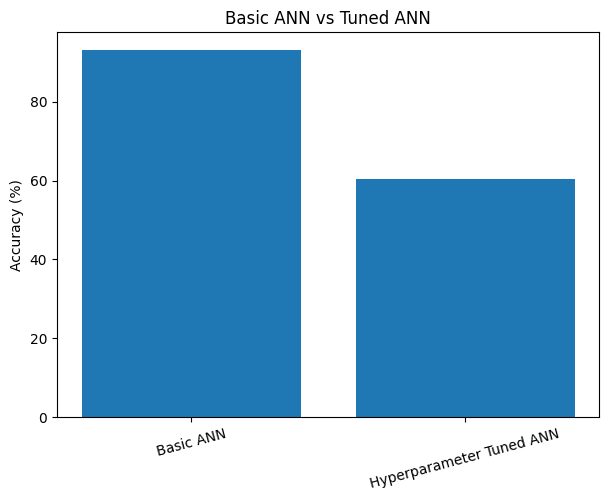

In [60]:
plt.figure(figsize=(7, 5))

plt.bar(
    results["Model"],
    results["Accuracy (%)"]
)

plt.ylabel("Accuracy (%)")
plt.title("Basic ANN vs Tuned ANN")

plt.xticks(rotation=15)

plt.show()

In [61]:
sample_mobile = X.iloc[[0]]

display(sample_mobile)

,battery_power,bluetooth,clock_speed,dual_sim,front_cam,4G,int_memory,m_dep,mobile_wt,n_cores,primary_camera,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1


In [62]:
sample_scaled = scaler.transform(
    sample_mobile
)

In [63]:
prediction_probability = tuned_model.predict(
    sample_scaled
)

predicted_class = np.argmax(
    prediction_probability,
    axis=1
)[0]

print(
    "Predicted Price Range:",
    predicted_class
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Predicted Price Range: 2


In [64]:
price_labels = {
    0: "Low Cost",
    1: "Medium Cost",
    2: "High Cost",
    3: "Very High Cost"
}

print(
    "Predicted Mobile Category:",
    price_labels[predicted_class]
)

Predicted Mobile Category: High Cost
